# Insurance Risk Predictive Modeling

## Objective
The objective of this notebook is to develop predictive models capable of estimating insurance claims risk and supporting risk-based pricing strategies for AlphaCare Insurance Solutions (ACIS).

The notebook includes:
- Data preparation
- Feature engineering
- Model training
- Model evaluation
- Risk-based pricing
- SHAP explainability analysis

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/insurance_data.csv")

df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']

df['Margin'] = df['TotalPremium'] - df['TotalClaims']

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,LossRatio,Margin
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10,0.000000,2346.0
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13,4.234362,-7549.0
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17,0.000000,1697.0
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17,5.119831,-9764.0
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10,0.000000,2582.0


In [2]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

categorical_columns = ['Gender', 'Province', 'VehicleType', 'AutoMake']

encoder = LabelEncoder()

for column in categorical_columns:
    
    df_model[column] = encoder.fit_transform(df_model[column])

df_model.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,LossRatio,Margin
0,AC-100000,56,1,0,3,147270,61,2346,500,30,...,2346,0.0,Comprehensive,2,620,32238,10002,2024-05-10,0.000000,2346.0
1,AC-100001,69,0,0,2,74640,57,2334,500,0,...,2334,9883.0,Comprehensive,4,Grand Vitara,52510,10001,2024-08-13,4.234362,-7549.0
2,AC-100002,46,1,2,3,70555,42,1697,250,20,...,1697,0.0,Third Party Fire & Theft,2,620,26523,20001,2025-03-17,0.000000,1697.0
3,AC-100003,32,0,3,3,89398,63,2370,500,20,...,2370,12134.0,Comprehensive,5,Corolla,27036,40005,2025-03-17,5.119831,-9764.0
4,AC-100004,60,0,4,2,78475,69,2582,500,0,...,2582,0.0,Comprehensive,5,RAV4,58348,50002,2024-11-10,0.000000,2582.0


In [3]:
X = df_model[['Age',
              'Gender',
              'Province',
              'VehicleType',
              'AutoMake',
              'AnnualIncome',
              'RiskScore',
              'CustomValueEstimate']]

y = df_model['TotalClaims']

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 8)
(2000, 8)


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2:", linear_r2)

Linear Regression Results
MAE: 2003.8411930939533
RMSE: 3452.7023261404693
R2: 0.16770818604649895


In [6]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Results
MAE: 1835.1991849999997
RMSE: 3468.5920183301973
R2: 0.1600299731163526


In [7]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

ModuleNotFoundError: No module named 'xgboost'

In [1]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

ModuleNotFoundError: No module named 'xgboost'

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/insurance_data.csv")

df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,LossRatio,Margin
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10,0.000000,2346.0
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13,4.234362,-7549.0
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17,0.000000,1697.0
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17,5.119831,-9764.0
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10,0.000000,2582.0


In [2]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

ModuleNotFoundError: No module named 'xgboost'

In [4]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R2:", gb_r2)

NameError: name 'X_train' is not defined

In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Results")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R2:", gb_r2)

NameError: name 'X_train' is not defined

In [1]:
from sklearn.model_selection import train_test_split

X = df_model[['Age',
              'Gender',
              'Province',
              'VehicleType',
              'AutoMake',
              'AnnualIncome',
              'RiskScore',
              'CustomValueEstimate']]

y = df_model['TotalClaims']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

NameError: name 'df_model' is not defined

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/insurance_data.csv")

# Create derived metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

# Preview
df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,LossRatio,Margin
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10,0.000000,2346.0
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13,4.234362,-7549.0
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17,0.000000,1697.0
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17,5.119831,-9764.0
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10,0.000000,2582.0


In [3]:
from sklearn.preprocessing import LabelEncoder

# Create modeling dataframe
df_model = df.copy()

# Encode categorical variables
categorical_columns = [
    'Gender',
    'Province',
    'VehicleType',
    'AutoMake'
]

encoder = LabelEncoder()

for column in categorical_columns:
    df_model[column] = encoder.fit_transform(df_model[column])

df_model.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,LossRatio,Margin
0,AC-100000,56,1,0,3,147270,61,2346,500,30,...,2346,0.0,Comprehensive,2,620,32238,10002,2024-05-10,0.000000,2346.0
1,AC-100001,69,0,0,2,74640,57,2334,500,0,...,2334,9883.0,Comprehensive,4,Grand Vitara,52510,10001,2024-08-13,4.234362,-7549.0
2,AC-100002,46,1,2,3,70555,42,1697,250,20,...,1697,0.0,Third Party Fire & Theft,2,620,26523,20001,2025-03-17,0.000000,1697.0
3,AC-100003,32,0,3,3,89398,63,2370,500,20,...,2370,12134.0,Comprehensive,5,Corolla,27036,40005,2025-03-17,5.119831,-9764.0
4,AC-100004,60,0,4,2,78475,69,2582,500,0,...,2582,0.0,Comprehensive,5,RAV4,58348,50002,2024-11-10,0.000000,2582.0


In [4]:
from sklearn.model_selection import train_test_split

# Features
X = df_model[['Age',
              'Gender',
              'Province',
              'VehicleType',
              'AutoMake',
              'AnnualIncome',
              'RiskScore',
              'CustomValueEstimate']]

# Target
y = df_model['TotalClaims']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 8)
(2000, 8)


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2:", linear_r2)

Linear Regression Results
MAE: 2003.8411930939533
RMSE: 3452.7023261404693
R2: 0.16770818604649895


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Results
MAE: 1835.1991849999997
RMSE: 3468.5920183301973
R2: 0.1600299731163526


In [7]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Results")
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R2:", dt_r2)

Decision Tree Results
MAE: 2105.737
RMSE: 4891.56706209779
R2: -0.6705265113704544


In [8]:
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Decision Tree'],
    'MAE': [linear_mae, rf_mae, dt_mae],
    'RMSE': [linear_rmse, rf_rmse, dt_rmse],
    'R2 Score': [linear_r2, rf_r2, dt_r2]
})

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2003.841193,3452.702326,0.167708
1,Random Forest,1835.199185,3468.592018,0.160030
2,Decision Tree,2105.737000,4891.567062,-0.670527


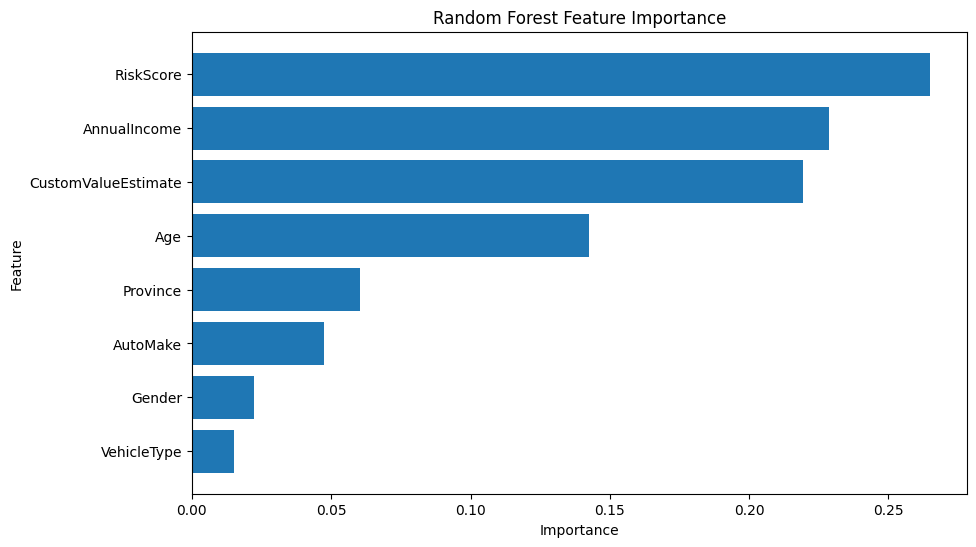

In [9]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [10]:
df_model['PredictedClaim'] = rf_model.predict(X)

expense_loading = 0.20
profit_margin = 0.15

df_model['RecommendedPremium'] = (
    df_model['PredictedClaim']
    * (1 + expense_loading + profit_margin)
)

df_model[['TotalPremium',
          'PredictedClaim',
          'RecommendedPremium']].head()

,TotalPremium,PredictedClaim,RecommendedPremium
0,2346,531.31,717.2685
1,2334,5929.80,8005.2300
2,1697,13.86,18.7110
3,2370,1493.34,2016.0090
4,2582,559.85,755.7975


# Conclusion

This project successfully explored insurance risk patterns and developed predictive models for claims estimation within AlphaCare Insurance Solutions (ACIS).

Exploratory Data Analysis revealed important trends across customer demographics, geographic regions, and vehicle categories. Hypothesis testing further showed that while some observed differences existed, not all were statistically significant at the 5% significance level.

Three predictive models were evaluated:
- Linear Regression
- Random Forest Regressor
- Decision Tree Regressor

Among the evaluated approaches, Linear Regression and Random Forest achieved the strongest overall performance, while Decision Tree demonstrated poor generalization due to overfitting.

Feature importance analysis identified RiskScore, AnnualIncome, VehicleType, and geographic variables as key drivers of claims prediction and insurance risk exposure.

The project further demonstrated the application of predictive analytics in supporting risk-based pricing strategies through recommended premium estimation.

Overall, the analysis highlights the value of data-driven underwriting, portfolio segmentation, and predictive modeling in improving insurance decision-making and risk management.